In [ ]:
import netCDF4 as nc 
import matplotlib.pyplot as plt
import numpy as np
import itertools
import xarray as xr
import glob

In [2]:
var = 'HLT'
files = glob.glob(f'{var}/*.nc')
files

['HLT/north200002.nc',
 'HLT/north200305.nc',
 'HLT/north199304.nc',
 'HLT/north201505.nc',
 'HLT/north201602.nc',
 'HLT/north201901.nc',
 'HLT/north201810.nc',
 'HLT/north199112.nc',
 'HLT/north199102.nc',
 'HLT/north201703.nc',
 'HLT/north201612.nc',
 'HLT/north201911.nc',
 'HLT/north201404.nc',
 'HLT/north199205.nc',
 'HLT/north200204.nc',
 'HLT/north202006.nc',
 'HLT/north200103.nc',
 'HLT/north200012.nc',
 'HLT/north200301.nc',
 'HLT/north200210.nc',
 'HLT/north201008.nc',
 'HLT/north199609.nc',
 'HLT/north202012.nc',
 'HLT/north200006.nc',
 'HLT/north200608.nc',
 'HLT/north201905.nc',
 'HLT/north201606.nc',
 'HLT/north201501.nc',
 'HLT/north199211.nc',
 'HLT/north201410.nc',
 'HLT/north199201.nc',
 'HLT/north201511.nc',
 'HLT/north199310.nc',
 'HLT/north199106.nc',
 'HLT/north201707.nc',
 'HLT/north201804.nc',
 'HLT/north200709.nc',
 'HLT/north202002.nc',
 'HLT/north200107.nc',
 'HLT/north199708.nc',
 'HLT/north201109.nc',
 'HLT/north200311.nc',
 'HLT/north200211.nc',
 'HLT/north

In [ ]:
damaged_files = []
files_with_nans = []
for file in files: 
    try:
        ds = xr.open_dataset(file)
        vals = ds[var].values
        if np.isnan(vals).any(): 
            print(f'{file} contain {np.isnan(vals).sum()} nans ({np.isnan(vals).sum() / vals.size * 100:.1f}%)')
            nan_idxs = np.argwhere(np.isnan(vals))
            print(f'nans from {nan_idxs[0]} to {nan_idxs[-1]}')
            files_with_nans.append(file)
        else: 
            continue
    except (RuntimeError, OSError) as e:
        print(f'Damaged file {file}: {e}')
        damaged_files.append(file)
        continue

if damaged_files: 
    ln=len(damaged_files)
    damaged_files = '\n'.join(damaged_files)
    print(f'{ln} damaged files: {damaged_files}')
else: 
    print('No damaged files')

if files_with_nans: 
    files_with_nans = '\n'.join(files_with_nans)
    print(f'{len(files_with_nans)} files with nans: {files_with_nans}')
else: 
    print('No files with nans')

HLT/north201810.nc contain 327600 nans (0.8%)
nans from [  0 122   0   0] to [  9 122  90 359]
HLT/north199112.nc contain 327600 nans (0.8%)
nans from [  0 120   0   0] to [  9 120  90 359]
HLT/north201612.nc contain 327600 nans (0.8%)
nans from [  0 120   0   0] to [  9 120  90 359]
HLT/north201911.nc contain 327600 nans (0.8%)
nans from [  0 119   0   0] to [  9 119  90 359]
HLT/north200012.nc contain 327600 nans (0.8%)
nans from [  0 120   0   0] to [  9 120  90 359]
HLT/north200210.nc contain 327600 nans (0.8%)
nans from [  0 122   0   0] to [  9 122  90 359]
HLT/north202012.nc contain 327600 nans (0.8%)
nans from [  0 120   0   0] to [  9 120  90 359]
HLT/north199211.nc contain 327600 nans (0.8%)
nans from [  0 119   0   0] to [  9 119  90 359]
HLT/north201410.nc contain 327600 nans (0.8%)
nans from [  0 122   0   0] to [  9 122  90 359]
HLT/north201511.nc contain 327600 nans (0.8%)
nans from [  0 119   0   0] to [  9 119  90 359]
HLT/north199310.nc contain 327600 nans (0.8%)
nans

In [5]:
damaged_files

'HLT/north202501.nc'

In [20]:
fl = 'HLT/north199112.nc'
#fl = files[0]
print(fl)
ds = xr.open_dataset(fl)
arr = ds[var].values
#arr = np.where(arr==0.0, np.nan, arr)
#arr = arr[arr!=0]
np.isnan(arr).any()
#np.argwhere(np.isnan(arr.flatten()))
np.argwhere(np.isnan(arr))

HLT/north199112.nc


array([[  0, 120,   0,   0],
       [  0, 120,   0,   1],
       [  0, 120,   0,   2],
       ...,
       [  9, 120,  90, 357],
       [  9, 120,  90, 358],
       [  9, 120,  90, 359]], shape=(327600, 4))

In [10]:
arr.flatten()[3996720]

np.float32(nan)

In [21]:
#E, D = ds[var].shape[:2]
#for en, day in itertools.product(range(E), range(D)): 
#    print(f'mem {en}, day {day}: {np.mean(ds[var][en, day, :])}')

In [22]:
#len(arr[arr<0]) / len(arr.flatten()) * 100

In [12]:
import pandas as pd
srs = pd.Series(arr.flatten())
srs.describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5])#.apply(lambda x: float(round(x, 4)))
srs.info()
#srs[srs.isna()]

<class 'pandas.core.series.Series'>
RangeIndex: 40294800 entries, 0 to 40294799
Series name: None
Non-Null Count     Dtype  
--------------     -----  
39967200 non-null  float32
dtypes: float32(1)
memory usage: 153.7 MB


In [16]:
#arr = np.array(ds[var][:], dtype=np.float64)
#arr = np.where(arr>=0, np.nan, arr)

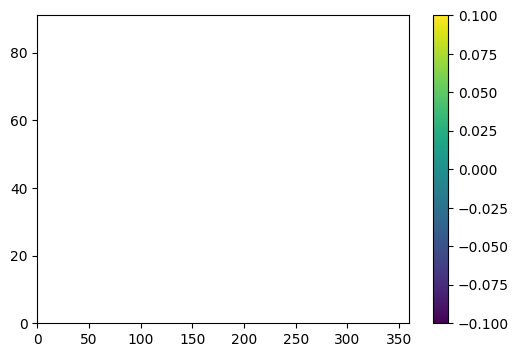

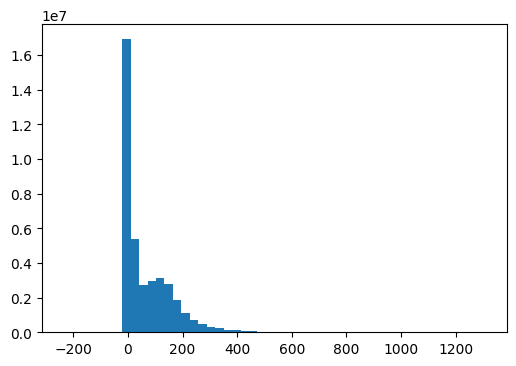

In [24]:
plt.figure(figsize=(6, 4))
plt.pcolormesh(arr[9, 120, :])#, origin='lower')
plt.colorbar()
plt.show()
plt.figure(figsize=(6, 4))
plt.hist(arr.flatten(), bins = 50)
plt.show()

In [1]:
ds = nc.Dataset('SS/north199302.nc')
ds

NameError: name 'nc' is not defined

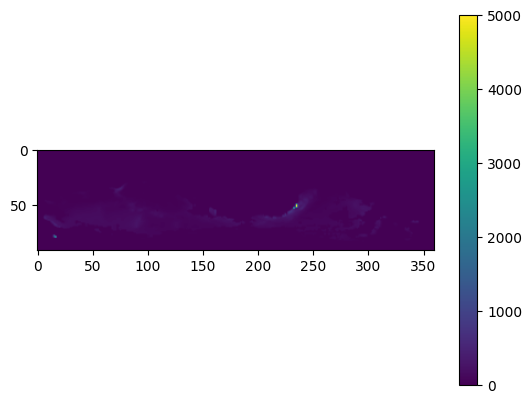

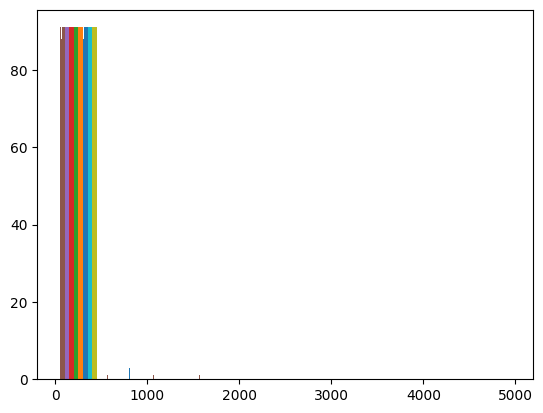

In [6]:
plt.imshow(ds['SS'][0, 0, :])
plt.colorbar()
plt.show()
plt.hist(ds['SS'][0, 0, :])
plt.show()

In [13]:
import xarray
import numpy as np

In [24]:
arr = ds['SS'][0, 0, :, :].flatten()
np.where(arr > 0)


(array([10523, 10524, 10525, ..., 30215, 30216, 30217], shape=(6020,)),)

In [25]:
arr[10523:10533]

masked_array(data=[4.7843823e-01, 1.5145788e+00, 2.7885118e+00,
                   1.5056474e+00, 5.4761583e-01, 7.3928475e-02,
                   5.7030644e-04, 0.0000000e+00, 0.0000000e+00,
                   0.0000000e+00],
             mask=False,
       fill_value=np.float64(1e+20),
            dtype=float32)

In [ ]:
arr